In [45]:
import os
import time
import umap
import yaml
import torch
import random
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as datetime 
import matplotlib.pyplot as plt 
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, Dataset, default_collate

from mm_cgmvae import *
from train_mmvae import*
from VAE_model_architectures import*

In [47]:
params = {
    'general': {
'dataset': 'DO',  # DO
'model_type': 'CGMVAE', # VAE or CVAE or GMVAE 
'random_seed': 85,
'learn_prior': False,
'accelerator': True,
'M': 2,
'epochs': 500,
'num_iwae_samples': 1, 
'learning_rate': 1e-3
    }
}

dataset = params['general']['dataset']
model_type = params['general']['model_type']
random_seed = params['general']['random_seed']
learn_prior = params['general']['learn_prior']
accelerator = params['general']['accelerator']
M = params['general']['M']
epochs = params['general']['epochs']
num_iwae_samples = params['general']['num_iwae_samples']
learning_rate = params['general']['learning_rate']

In [48]:
if dataset == 'AD':
    dataset_params = {
    'input_dim': [4842, 4850],
    'H1': [128, 128], 
    'H2': [64, 64], 
    'H3': [32, 32],
    'latent_dim': 10,
    'batch_size': 271, # divided by length, 9751 / 971 leaves last batch = 271
    'scales': [1, 1],
    'dataset_abbrev': ['HC', 'PFC'],
    'output_folder': '/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr/test',
    'input_path': '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/hc_pfc_adbxd_paired_30perc.csv',
    #'input_path': '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/sampletest_hc_pfc_adbxd_paired.csv',
    'gmm_centers_path': '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/gmm_centers_4gaussian_14mon_fromQRT.csv',
    'gmm_std': 2,
    'num_classes': 4,
    'num_kl_samples': 100
    }
elif dataset == 'DO':
    dataset_params = {
    'input_dim': [5873, 36],
    'H1': [128, 35], 
    'H2': [64, 16], 
    'H3': [32, 10],
    'latent_dim': 10,
    'batch_size': 271, # divided by length, 9751 / 971 leaves last batch = 271
    'scales': [1, 1],
    'dataset_abbrev': ['Geno', 'Physio'],
    'output_folder': '/home/rachel/Desktop/mm-vae results/caloric_restriction_DO_mice/vanillavae4_genoreweighted_test',
    'input_path': '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/joined_genetic_physio_cfc.csv',
    #'input_path': '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/joined_genetic_physio.csv',
    'gmm_centers_path': '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/gmm_centers_4gaussian_14mon_fromQRT.csv',
    'gmm_std': 2,
    'num_classes': 4,
    'num_kl_samples': 100
    }
params['dataset_params'] = dataset_params
input_dim = params['dataset_params']['input_dim']
H1 = params['dataset_params']['H1']
H2 = params['dataset_params']['H2']
H3 = params['dataset_params']['H3']
latent_dim = params['dataset_params']['latent_dim']
batch_size = params['dataset_params']['batch_size']
scales = params['dataset_params']['scales']
dataset_abbrev = params['dataset_params']['dataset_abbrev']
output_folder = params['dataset_params']['output_folder']
input_path = params['dataset_params']['input_path']
gmm_centers_path = params['dataset_params']['gmm_centers_path']
gmm_std = params['dataset_params']['gmm_std']
num_classes = params['dataset_params']['num_classes']
num_kl_samples = params['dataset_params']['num_classes']

In [49]:
# initialize device 
# set device to gpu if available 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# create output folder 
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# save params in a yaml file 
with open(f"{output_folder}/config.yaml", "w") as f:
    yaml.dump(params, f)

In [50]:
# set seed
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
# # set seed
# os.environ["PYTHONHASHSEED"] = str(random_seed)
# os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"

# def set_seed(seed: int = random_seed):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)
#     torch.backends.cudnn.deterministic = True
#     torch.backends.cudnn.benchmark = False
#     torch.use_deterministic_algorithms(True)
# set_seed(random_seed)

In [51]:
def standardizer(input_array):
    mean = np.mean(input_array)
    std = np.std(input_array)
    return (input_array - mean)/std

def numpyToTensor(x):
    return torch.from_numpy(x)

In [52]:
paired_df = pd.read_csv(input_path, low_memory=False)
paired_df

,MouseID,0,1,2,3,4,5,6,7,8,...,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num,Diet,Mouse.ID,CFC.24mo.Average,cfc_bin
0,DO-1D-3001,11.181311,12.383703,13.223754,18.683861,-3.105873,15.071812,4.566722,-8.317668,15.178740,...,-0.282162,-0.284390,-0.302189,-0.302202,-0.302199,4,1D,DO-1D-3001,0.84,0
1,DO-1D-3003,14.611459,-0.662600,-24.308638,-22.627848,-18.261186,1.859805,6.543754,22.646550,-1.809972,...,-0.284586,-0.287381,-0.302189,-0.302203,-0.302198,4,1D,DO-1D-3003,83.69,8
2,DO-1D-3010,1.859422,-7.514837,1.146809,-10.576791,-14.123598,0.187016,2.846669,-21.453514,-14.552152,...,-0.283942,-0.284049,-0.302189,-0.302203,-0.302205,4,1D,DO-1D-3010,36.71,3
3,DO-1D-3011,6.336620,-19.787761,9.017313,-4.479619,12.846408,-5.231286,16.983432,-16.252265,-12.688484,...,-0.281745,-0.281171,-0.302189,-0.302205,-0.302193,4,1D,DO-1D-3011,21.96,2
4,DO-1D-3013,-23.926661,-7.046359,8.830735,1.312327,-0.527705,6.687224,-9.731708,6.568401,6.597907,...,-0.283412,-0.294808,-0.302189,-0.302202,-0.302156,4,1D,DO-1D-3013,6.93,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,DO-AL-0186,-5.162836,8.648018,-1.372207,10.970472,-1.921667,-3.733688,8.676810,-16.461100,-8.221440,...,-0.281315,-0.294808,-0.302211,-0.302210,-0.302156,5,AL,DO-AL-0186,20.44,2
497,DO-AL-0188,11.180352,-8.517944,8.474807,-6.834697,12.355449,20.439765,11.830693,-11.656498,-24.270286,...,-0.280596,-0.283513,-0.302216,-0.302200,-0.302202,5,AL,DO-AL-0188,18.31,1
498,DO-AL-0191,3.404846,0.426192,-2.073981,-12.920995,-19.462683,6.055004,9.646308,4.292594,10.025039,...,-0.282754,-0.294808,-0.302207,-0.302194,-0.302156,5,AL,DO-AL-0191,24.71,2
499,DO-1D-3083,-20.852529,7.764088,-5.252014,8.705888,-11.405415,13.622378,1.249871,8.666080,14.656721,...,-0.274878,-0.277799,-0.302223,-0.302210,-0.302199,4,1D,DO-1D-3083,31.07,3


In [76]:
class PairedDataset(Dataset):
    def __init__(self, paired_df, input_dims, label_col, cfm_col, dataset):
        self.paired_df = paired_df
        if dataset == 'AD':
            self.df1_layer1, self.x1, self.label1, self.cfm1, self.df2_layer1, self.x2, self.label2, self.cfm2 = load_pairedregion_data(paired_df, input_dims[0], input_dims[1], label_col, cfm_col)
        elif dataset == 'DO': 
            self.df1_layer1, self.x1, self.label1, self.cfm1, self.df2_layer1, self.x2, self.label2, self.cfm2 = load_pairedmodal_data(paired_df, input_dims[0], label_col, cfm_col)
        self.df1_layer1 = numpyToTensor(self.df1_layer1)
        self.x1 = numpyToTensor(self.x1)
        self.cfm1 = numpyToTensor(self.cfm1)
        self.label1 = numpyToTensor(self.label1)

        self.df2_layer1 = numpyToTensor(self.df2_layer1)
        self.x2 = numpyToTensor(self.x2)
        self.cfm2 = numpyToTensor(self.cfm2)
        self.label2 = numpyToTensor(self.label2)

    def __len__(self):
        return len(self.paired_df)
    def __getitem__(self, index):
        return (self.df1_layer1[index], self.x1[index], self.label1[index], self.cfm1[index]), (self.df2_layer1[index], self.x2[index], self.label2[index], self.cfm2[index])
    
def load_pairedregion_data(df, input_dim1, input_dim2, label_col, cfm_col):
    x1 = df[list(df.columns[0:input_dim1])].values.astype('float32')
    label1 = df[label_col].values
    cfm1 = df[cfm_col].values
    df1_layer1 = df[list(df.columns[0:input_dim1])].copy()
    df1_layer1['cfm'] = cfm1
    df1_layer1 = df1_layer1.values.astype('float32')

    x2 = df[list(df.columns[4852:4852+input_dim2])].values.astype('float32')
    label2 = df[label_col].values
    cfm2 = df[cfm_col].values
    df2_layer1 = df[list(df.columns[4852:4852+input_dim2])].copy()
    df2_layer1['cfm'] = cfm2
    df2_layer1 = df2_layer1.values.astype('float32')

    return df1_layer1, x1, label1, cfm1, df2_layer1, x2, label2, cfm2

def load_pairedmodal_data(df, input_dim1, label_col, cfm_col):
    x1 = df.iloc[:, 1:input_dim1+1].values.astype('float32')
    label1 = df[label_col].values
    cfm1 = df[cfm_col].values
    df1_layer1 = df.iloc[:, 1:input_dim1+1].copy()
    df1_layer1['cfm'] = cfm1
    df1_layer1 = df1_layer1.values.astype('float32')

    x2 = df.iloc[:, input_dim[0]+1:-5].values.astype('float32')
    label2 = df[label_col].values
    cfm2 = df[cfm_col].values
    df2_layer1 = df.iloc[:, input_dim[0]+1:-5].copy()
    df2_layer1['cfm'] = cfm2
    df2_layer1 = df2_layer1.values.astype('float32')

    return df1_layer1, x1, label1, cfm1, df2_layer1, x2, label2, cfm2

In [8]:
# will need to make dataloaders for DO dataset after I decide how to structure the model input

In [77]:
paired_df = pd.read_csv(input_path, low_memory=False)
if dataset == 'AD':
    label_col = '14-6-Bin_HC'
    cfm_col = 'CFM_14_5_snRNA_HC'
    paired_df[cfm_col] = standardizer(paired_df[cfm_col])
    paired_df[cfm_col] = standardizer(paired_df[cfm_col])
    meta = {
            'strain': paired_df['strain'],
            '14-6-residual': paired_df['14-6-residual_HC']
        }
    paired_df_train = paired_df.sample(frac=1, random_state=random_seed)
    train_dataset = PairedDataset(paired_df_train, input_dim, label_col, cfm_col, dataset)
    test_dataset = PairedDataset(paired_df, input_dim, label_col, cfm_col, dataset)
elif dataset == 'DO':
    label_col = 'cfc_bin'
    cfm_col = 'CFC.24mo.Average'
    paired_df[cfm_col] = standardizer(paired_df[cfm_col])
    meta = {
        'mouse_id': paired_df['Mouse.ID'], 
        'diet': paired_df['Diet']
    } 
    paired_df_train = paired_df.sample(frac=1, random_state=random_seed)
    train_dataset = PairedDataset(paired_df_train, input_dim, label_col, cfm_col, dataset)
    test_data = PairedDataset(paired_df, input_dim, label_col, cfm_col, dataset)

In [78]:
train_loader = DataLoader(train_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

In [81]:
first_iter = next(iter(train_loader))
first_iter[0][0].shape

torch.Size([271, 5874])

In [94]:
if model_type == 'CGMVAE':
    gmm_centers = pd.read_csv(gmm_centers_path)
    gmm_centers = gmm_centers.iloc[:, 1:].T
    ks_weight, cv_weight, samples, components = estimate_loss_coefficients(batch_size, torch.tensor([gmm_centers.values]).float().squeeze(), gmm_std, num_kl_samples)
    model = MM_CGMVAE(input_dim, H1, H2, H3, latent_dim, scales, num_classes, torch.tensor([gmm_centers.values]).float().squeeze(), gmm_std, ks_weight, cv_weight)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, amsgrad=False)

In [12]:
# initialize loss vectors
total_loss = []
total_test_loss = []
test_epochs = []
individual_loss = {}
recon_loss = {}
mse_losses = {}
mse_cfm_losses = {}
for i, set in enumerate(dataset_abbrev): 
    individual_loss[set] = {}
    individual_loss[set]['lpx_z'] = []
    individual_loss[set]['kls'] = []
    recon_loss[set] = {}
    mse_losses[set] = {}
    mse_cfm_losses[set] =  {}
    if i ==  0:
        recon_loss[set][set] = []
        recon_loss[set][dataset_abbrev[i+1]] = []
        mse_losses[set][set] = []
        mse_losses[set][dataset_abbrev[i+1]] = []
        mse_cfm_losses[set][set] = []
        mse_cfm_losses[set][dataset_abbrev[i+1]] = []
    else:
        recon_loss[set][set] = []
        recon_loss[set][dataset_abbrev[i-1]] = []
        mse_losses[set][set] = []
        mse_losses[set][dataset_abbrev[i-1]] = []
        mse_cfm_losses[set][set] = []
        mse_cfm_losses[set][dataset_abbrev[i-1]] = []

In [13]:
start_time = time.time()
for epoch in range(1, epochs+1):
    loss, lpx_zs, kls, lpxz_ind, mse_loss, mse_cfm_loss = train(epoch, model, optimizer, train_loader, num_iwae_samples, device, epochs, model_type)
    print('one iteration done')
    total_loss.append(loss)
    for i, set in enumerate(dataset_abbrev): 
        individual_loss[set]['lpx_z'].append(lpx_zs[i]) 
        individual_loss[set]['kls'].append(kls[i])
        if i ==  0:
            recon_loss[set][set].append(lpxz_ind[0] / len(train_loader))
            recon_loss[set][dataset_abbrev[i+1]].append(lpxz_ind[1] / len(train_loader))
            mse_losses[set][set].append(mse_loss[0])
            mse_losses[set][dataset_abbrev[i+1]].append(mse_loss[1])
            mse_cfm_losses[set][set].append(mse_cfm_loss[0])
            mse_cfm_losses[set][dataset_abbrev[i+1]].append(mse_cfm_loss[1])
        else:
            recon_loss[set][set].append(lpxz_ind[3] / len(train_loader))
            recon_loss[set][dataset_abbrev[i-1]].append(lpxz_ind[2] / len(train_loader))
            mse_losses[set][set].append(mse_loss[3])
            mse_losses[set][dataset_abbrev[i-1]].append(mse_loss[2])
            mse_cfm_losses[set][set].append(mse_cfm_loss[3])
            mse_cfm_losses[set][dataset_abbrev[i-1]].append(mse_cfm_loss[2])
    if epoch in [epochs / 2, epochs]:
        test_epochs.append(epoch)
        test(epoch, model, optimizer, test_loader, num_iwae_samples, device, output_folder, dataset_abbrev, meta)
end_time = time.time()
print(str(end_time - start_time) + ' seconds for training/testing')

====> Epoch: 001 Train loss: 24340.1015
one iteration done
====> Epoch: 002 Train loss: 23607.7534
one iteration done
====> Epoch: 003 Train loss: 22254.6301
one iteration done
====> Epoch: 004 Train loss: 19870.9222
one iteration done
====> Epoch: 005 Train loss: 17147.9272
one iteration done
====> Epoch: 006 Train loss: 15582.2635
one iteration done
====> Epoch: 007 Train loss: 13916.2448
one iteration done
====> Epoch: 008 Train loss: 12016.9684
one iteration done
====> Epoch: 009 Train loss: 9879.3954
one iteration done
====> Epoch: 010 Train loss: 7806.8738
one iteration done
====> Epoch: 011 Train loss: 6062.5220
one iteration done
====> Epoch: 012 Train loss: 4679.7669
one iteration done
====> Epoch: 013 Train loss: 3845.4274
one iteration done
====> Epoch: 014 Train loss: 3212.7721
one iteration done
====> Epoch: 015 Train loss: 2880.4204
one iteration done
====> Epoch: 016 Train loss: 2597.4093
one iteration done
====> Epoch: 017 Train loss: 2403.8658
one iteration done
====> 

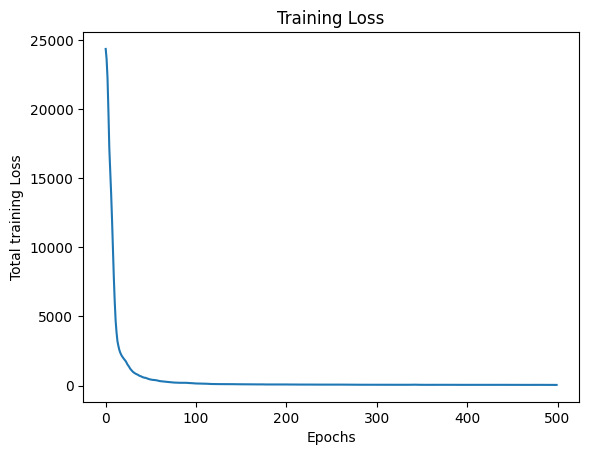

In [14]:
plt.figure()
plt.plot(total_loss, label='Training loss')                                                                          
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Total training Loss')            
plt.savefig(os.path.join(output_folder, 'train_loss.png'))

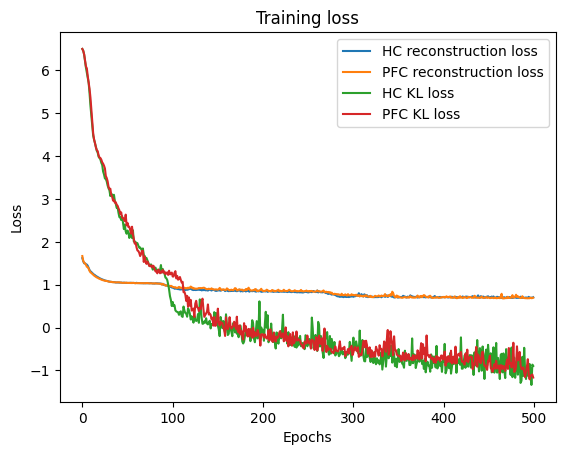

In [15]:
plt.figure()
names = ['reconstruction loss', 'KL loss']
for i, set in enumerate(['lpx_z', 'kls']):
    for j, abbrev in enumerate(dataset_abbrev):
        plt.plot(np.log(individual_loss[dataset_abbrev[j]][set]), label=f'{dataset_abbrev[j]} {names[i]}')
plt.title('Training loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(os.path.join(output_folder, 'recon_kl_oneplot.png'))

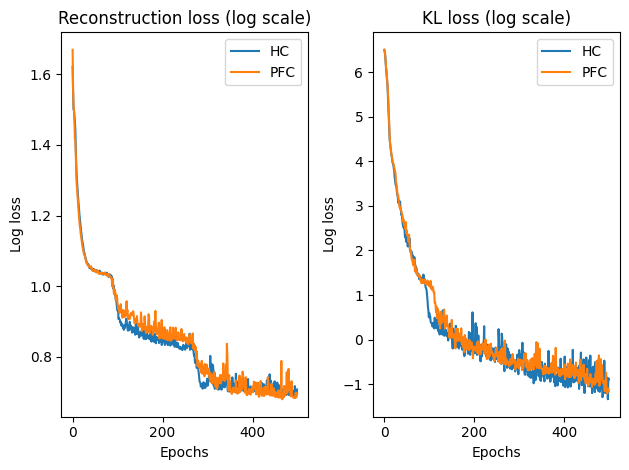

In [16]:
fig, ax = plt.subplots(1, 2)
names = ['Reconstruction loss', 'KL loss']
for i, set in enumerate(['lpx_z', 'kls']):
    for j, abbrev in enumerate(dataset_abbrev):
        ax[i].plot(np.log(individual_loss[dataset_abbrev[j]][set]), label=f'{dataset_abbrev[j]}')
    ax[i].set_title(f'{names[i]} (log scale)')
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Log loss')
    ax[i].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'individual_loss_graphs_log.png'))

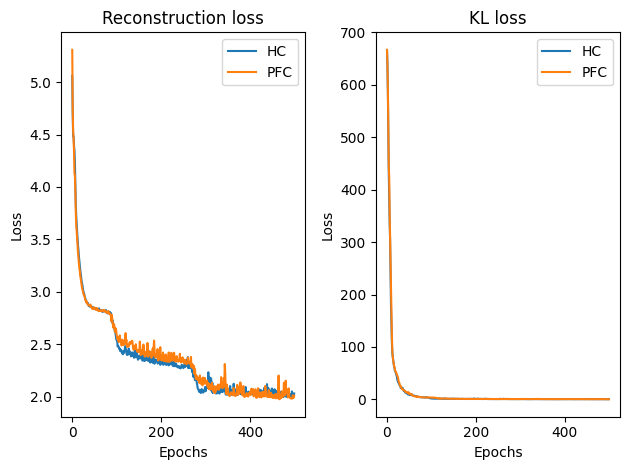

In [17]:
fig, ax = plt.subplots(1, 2)
names = ['Reconstruction loss', 'KL loss']
for i, set in enumerate(['lpx_z', 'kls']):
    for j, abbrev in enumerate(dataset_abbrev):
        ax[i].plot(individual_loss[dataset_abbrev[j]][set], label=f'{dataset_abbrev[j]}')
    ax[i].set_title(names[i])
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Loss')
    ax[i].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'individual_loss_graphs.png'))

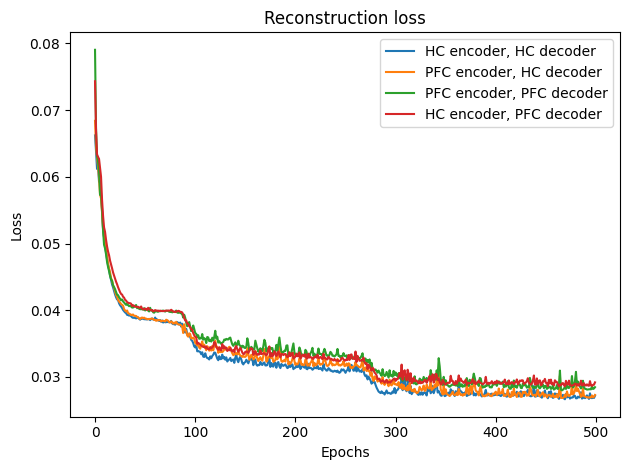

In [18]:
# Plotting each kind of reconstruction
for i, set in enumerate(dataset_abbrev):
    plt.plot((recon_loss[set][set]), label=f'{set} encoder, {set} decoder')
    if i == 0:
        plt.plot((recon_loss[dataset_abbrev[i+1]][set]), label=f'{dataset_abbrev[i+1]} encoder, {set} decoder')
    else: 
        plt.plot((recon_loss[dataset_abbrev[i-1]][set]), label=f'{dataset_abbrev[i-1]} encoder, {set} decoder')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Reconstruction loss')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_recon_loss_graphs.png'))

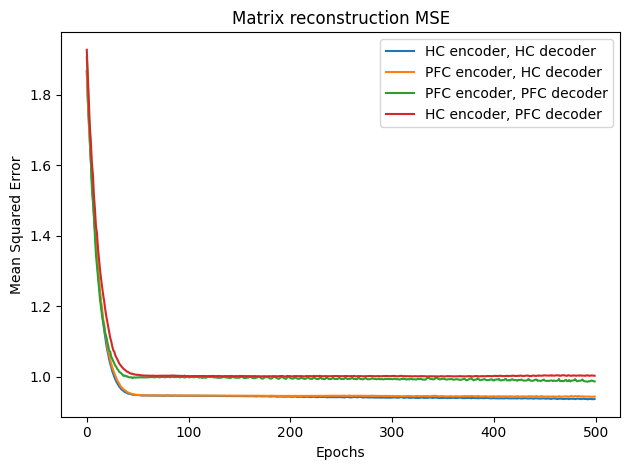

In [19]:
# Plotting each kind of reconstruction
for i, set in enumerate(dataset_abbrev):
    plt.plot(mse_losses[set][set], label=f'{set} encoder, {set} decoder')
    if i == 0:
        plt.plot((mse_losses[dataset_abbrev[i+1]][set]), label=f'{dataset_abbrev[i+1]} encoder, {set} decoder')
    else: 
        plt.plot((mse_losses[dataset_abbrev[i-1]][set]), label=f'{dataset_abbrev[i-1]} encoder, {set} decoder')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Matrix reconstruction MSE')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_mse_graphs.png'))

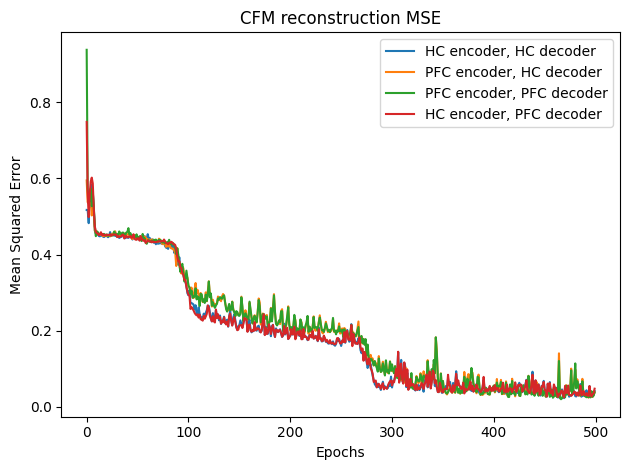

In [20]:
# Plotting each kind of reconstruction (cfm mse)
for i, set in enumerate(dataset_abbrev):
    plt.plot(mse_cfm_losses[set][set], label=f'{set} encoder, {set} decoder')
    if i == 0:
        plt.plot((mse_cfm_losses[dataset_abbrev[i+1]][set]), label=f'{dataset_abbrev[i+1]} encoder, {set} decoder')
    else: 
        plt.plot((mse_cfm_losses[dataset_abbrev[i-1]][set]), label=f'{dataset_abbrev[i-1]} encoder, {set} decoder')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('CFM reconstruction MSE')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_mse_cfm_graphs.png'))

Visualizing the latent space

In [21]:
hues=['encoder', 'bin']

In [22]:
latent_space_1 = latent_space_1 = pd.read_csv(os.path.join(output_folder, f'latent_variables_epoch{epochs}_vae{dataset_abbrev[0]}.csv'), index_col=False)
latent_space_2 = latent_space_2 = pd.read_csv(os.path.join(output_folder, f'latent_variables_epoch{epochs}_vae{dataset_abbrev[1]}.csv'), index_col=False)

In [23]:
latent_space_1.columns = latent_space_1.columns.str.replace(f'_{dataset_abbrev[0]}', '')
latent_space_2.columns = latent_space_2.columns.str.replace(f'_{dataset_abbrev[1]}', '')

In [24]:
latent_space_1

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,bin,cfm,encoder,strain,14-6-residual
0,-7.479042,-4.020054,3.948952,9.287516,13.878343,18.664614,25.933447,29.904715,37.919540,42.849860,3,1.243151,HC,124,1.277393
1,-9.518166,-7.807666,0.457554,6.326250,11.587746,16.721533,23.977425,27.908922,36.598980,41.222317,3,1.243151,HC,124,1.277393
2,-12.056219,-4.378871,0.668768,10.230970,17.237400,20.933376,28.936855,33.408130,42.883904,48.390083,3,1.243151,HC,124,1.277393
3,-9.593423,-2.543689,0.700873,6.399019,11.267654,17.059387,24.030216,28.396887,36.976524,41.518345,3,1.243151,HC,124,1.277393
4,-10.900582,-5.387421,0.944852,9.118219,15.392968,20.327919,27.973110,32.215736,41.309654,46.779324,3,1.243151,HC,124,1.277393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,-30.479149,-23.863848,-22.204123,-18.269648,-13.482140,-10.170998,-7.066227,-2.615886,-0.083563,5.362084,1,-0.215123,HC,28,-0.576731
9747,-28.206806,-20.746530,-19.795006,-12.949143,-6.902396,-5.805633,-1.244097,2.482728,6.471461,12.210671,1,-0.215123,HC,28,-0.576731
9748,-24.180593,-20.040022,-18.522945,-16.208912,-0.248492,-14.016491,-11.040559,-6.690119,-5.490116,-2.967590,1,-0.215123,HC,28,-0.576731
9749,-32.284473,-25.556370,-23.789560,-19.621530,-14.486710,-11.612892,-8.680565,-3.855368,-1.541887,3.863931,1,-0.215123,HC,28,-0.576731


In [25]:
latent_space_comb = pd.concat([latent_space_1, latent_space_2])
latent_space_comb = latent_space_comb.reset_index(drop=True)

In [26]:
prior_samples = pd.DataFrame(samples)
prior_samples['components'] = components

<Axes: xlabel='LV1', ylabel='Density'>

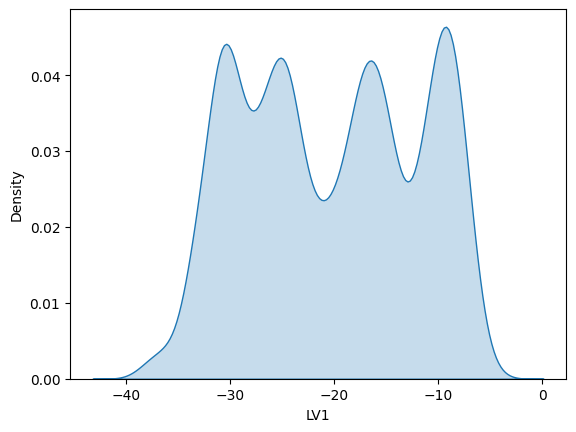

In [27]:
sns.kdeplot(data=latent_space_comb['LV1'], fill=True)

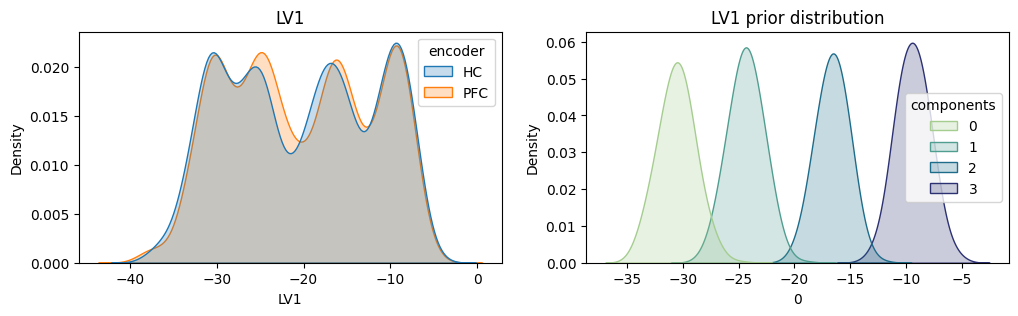

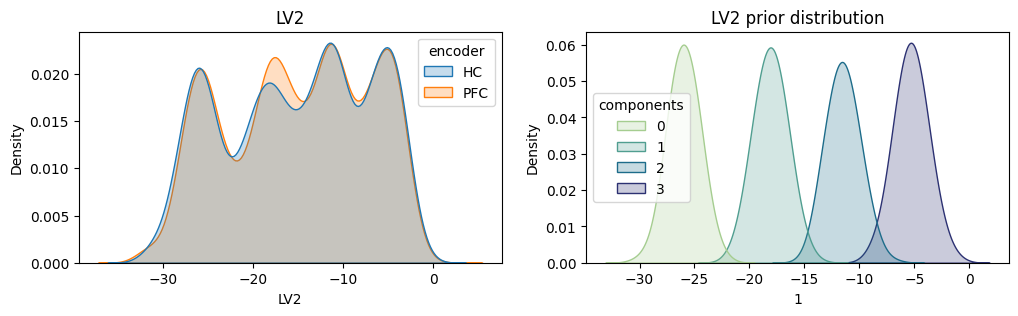

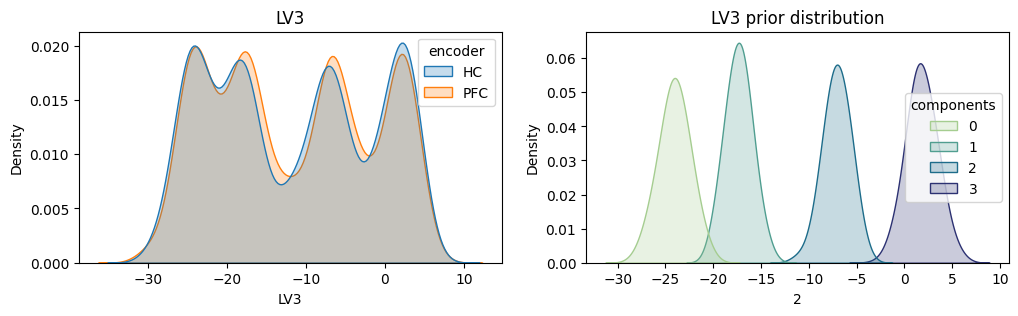

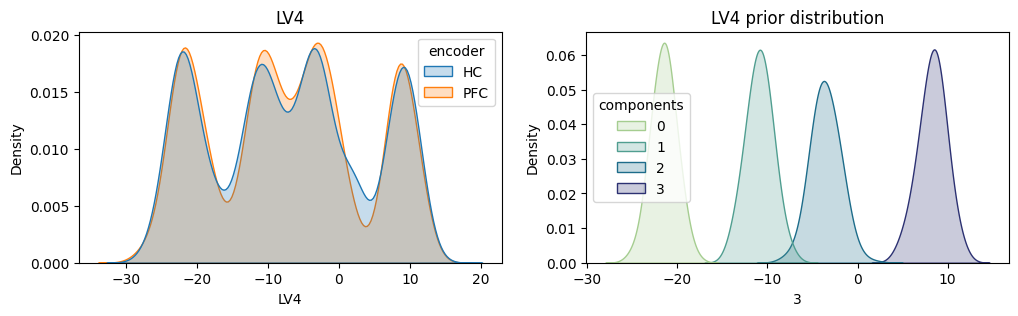

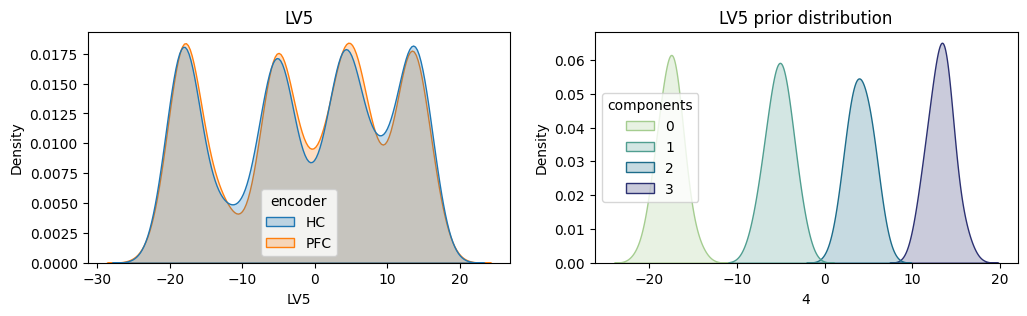

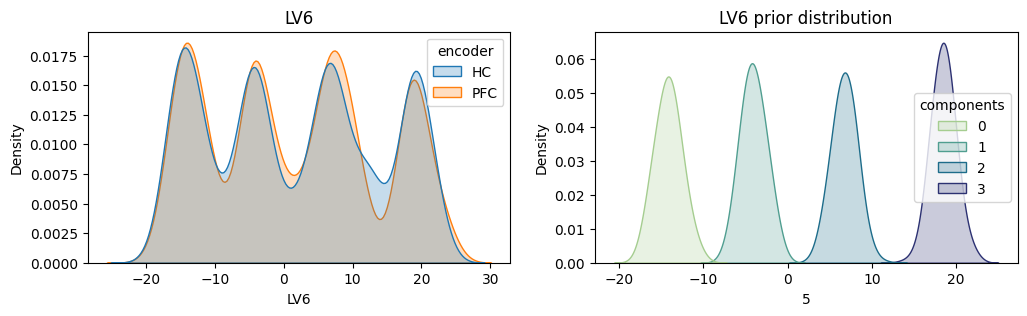

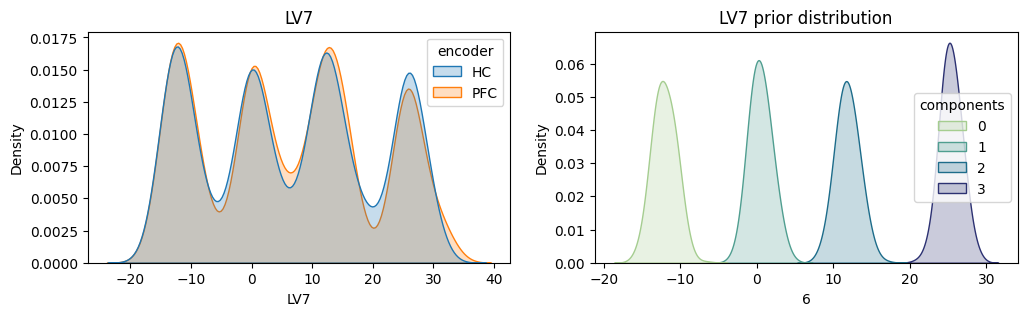

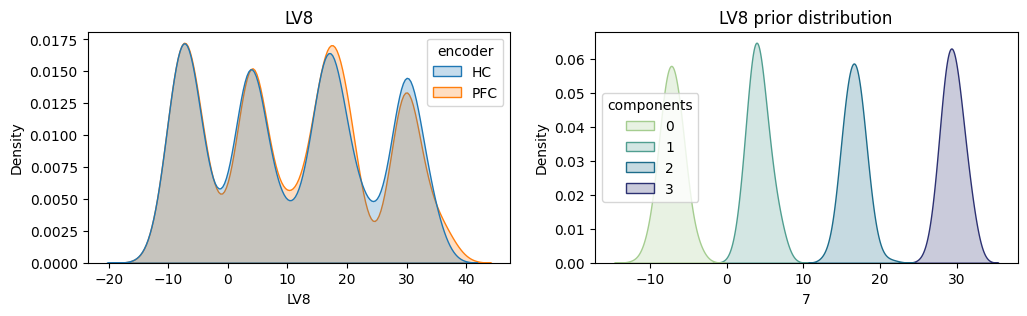

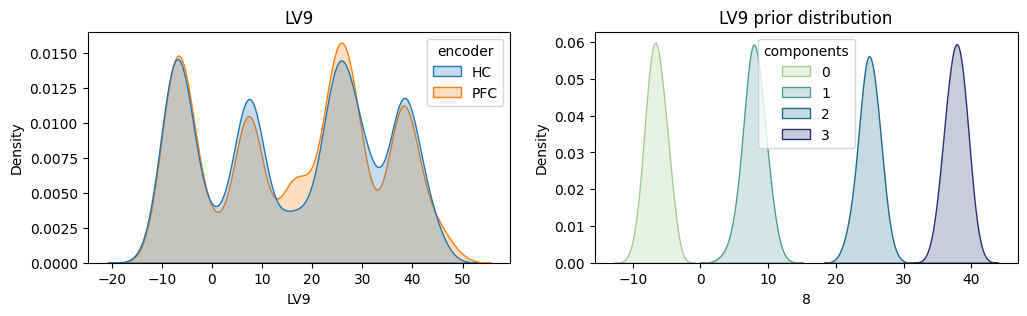

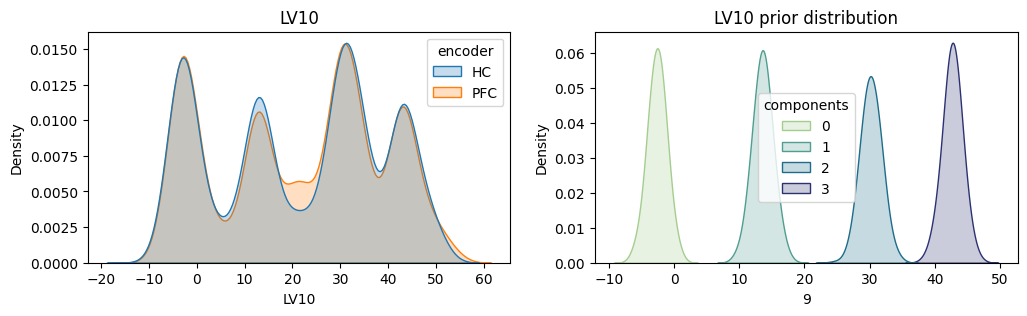

In [28]:
for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    sns.kdeplot(data=latent_space_comb[[column, 'encoder']], x=column, hue='encoder', fill=True, bw_adjust=1, ax=ax[0])
    ax[0].set_title(column)
    prior_col = prior_samples.columns[i]
    sns.kdeplot(data=prior_samples[[prior_col, 'components']], x=prior_col, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(f'{column} prior distribution')

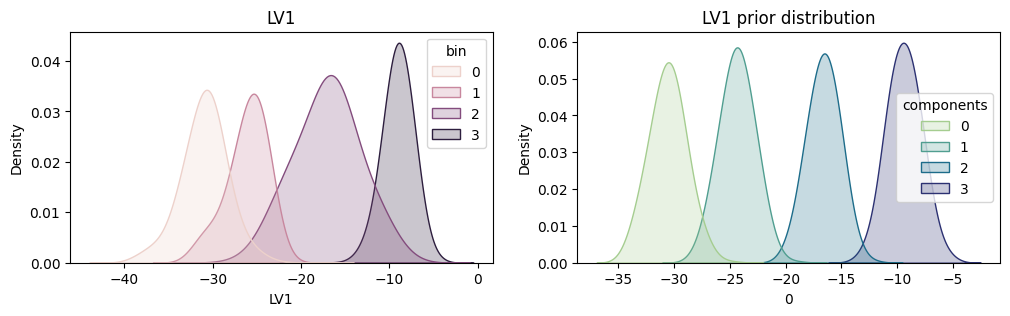

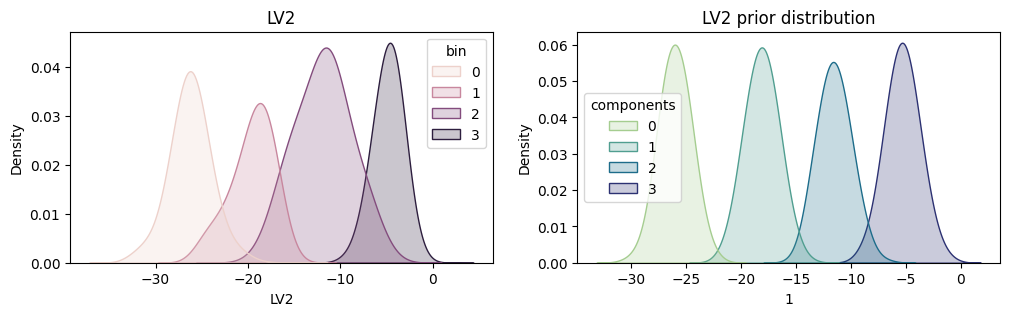

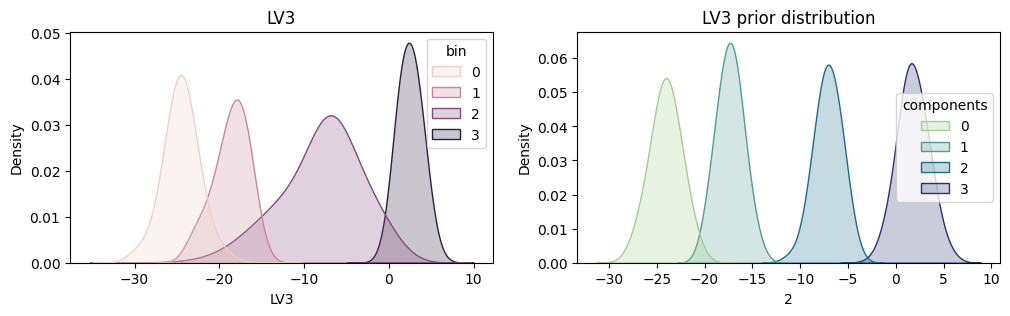

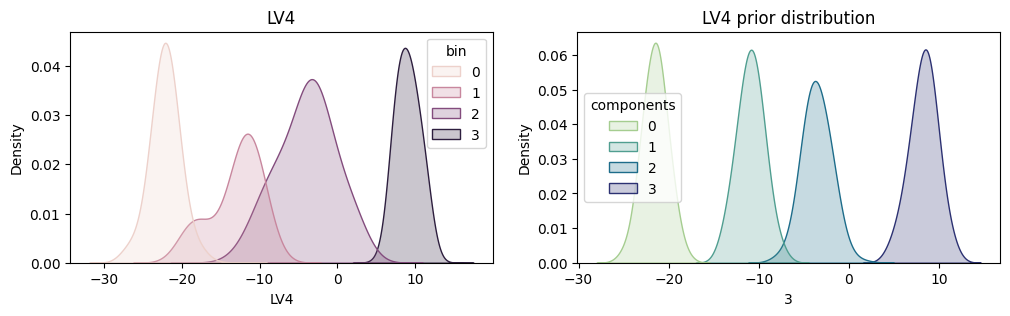

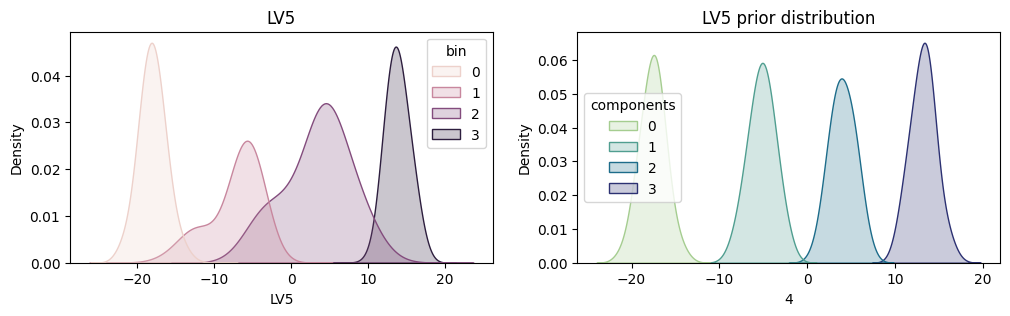

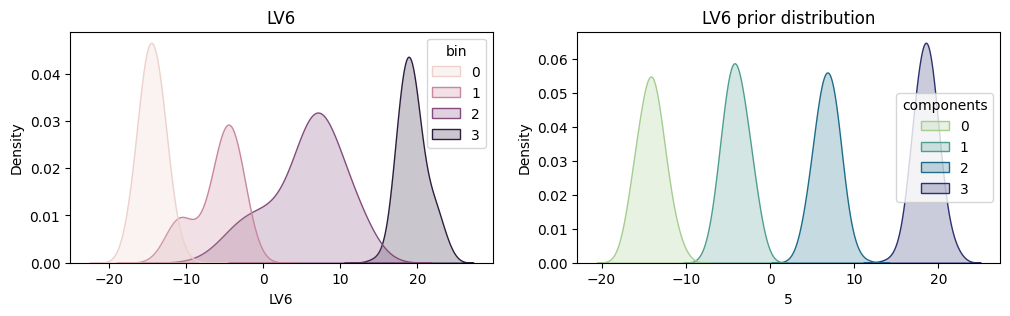

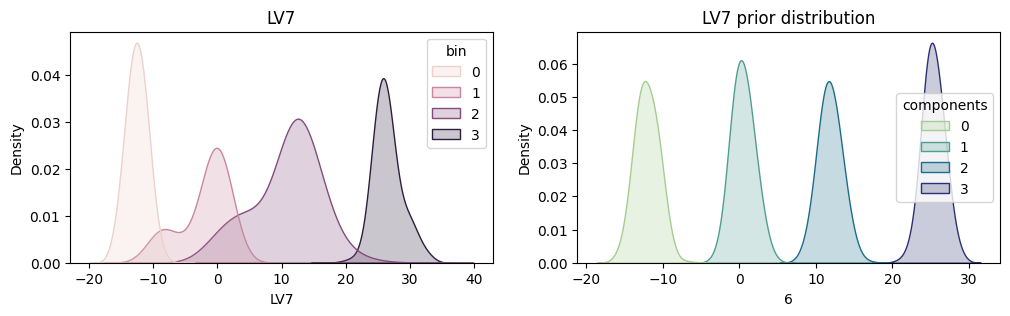

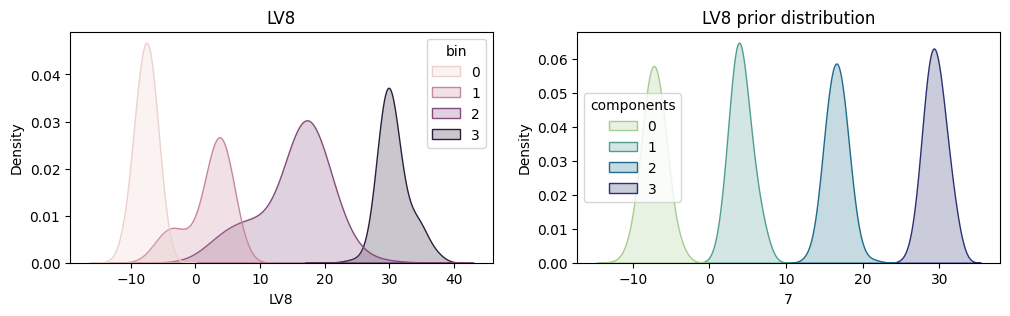

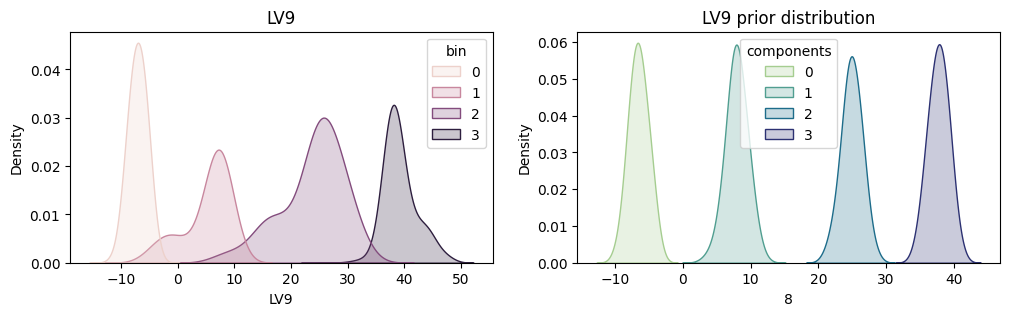

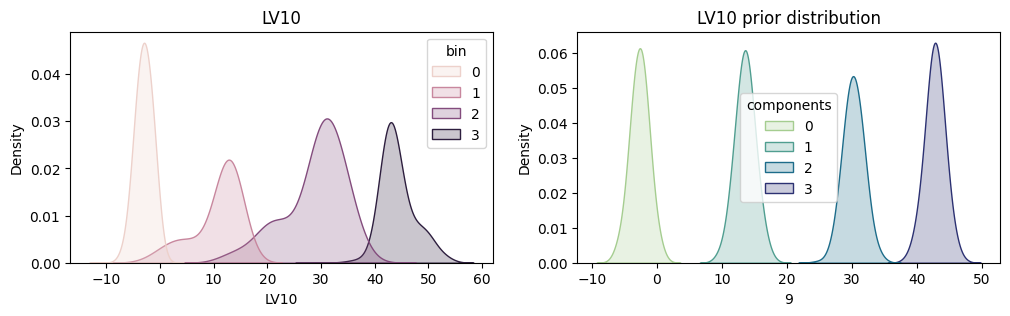

In [29]:
for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    sns.kdeplot(data=latent_space_comb[[column, 'bin']], x=column, hue='bin', fill=True, bw_adjust=3, ax=ax[0])
    ax[0].set_title(column)
    prior_col = prior_samples.columns[i]
    sns.kdeplot(data=prior_samples[[prior_col, 'components']], x=prior_col, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(f'{column} prior distribution')

In [95]:
latent_space_comb['bin_enc'] = latent_space_comb['bin'].astype(str) + '_' +  latent_space_comb['encoder']

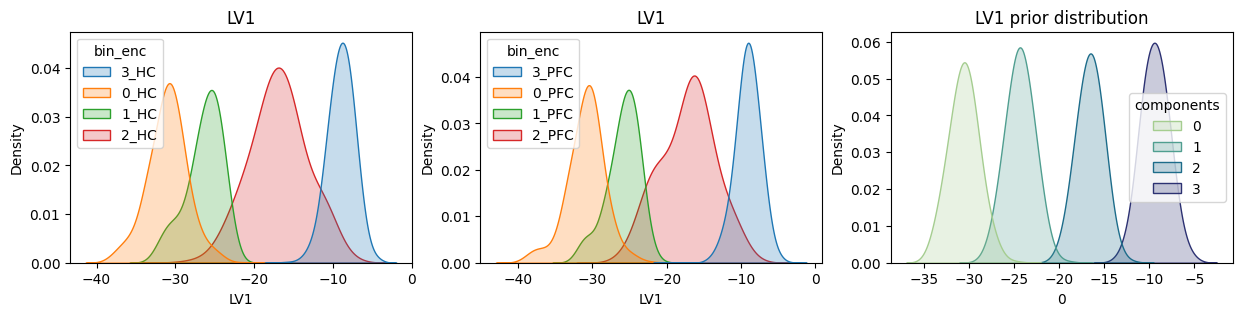

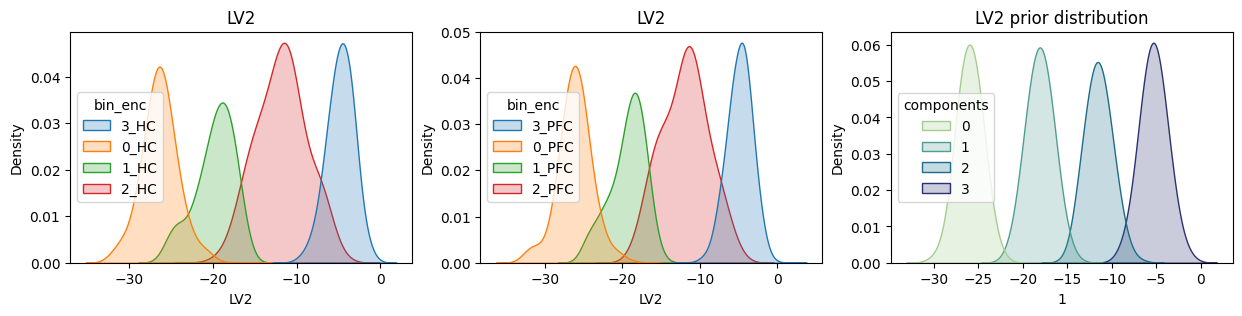

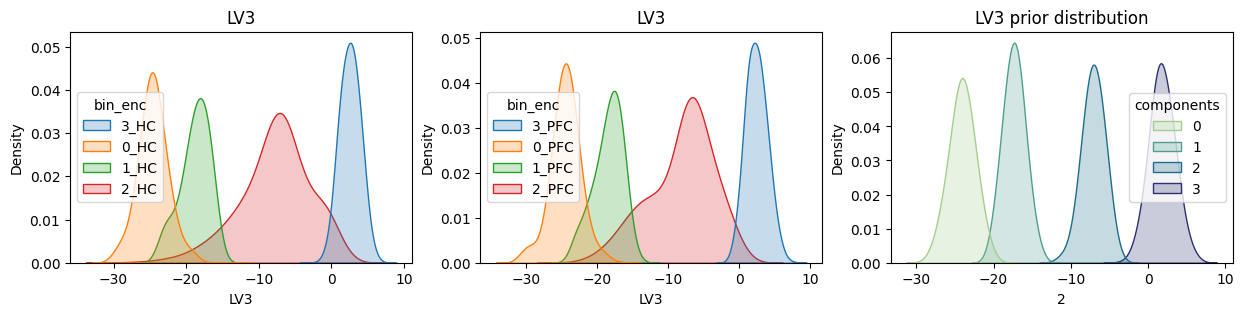

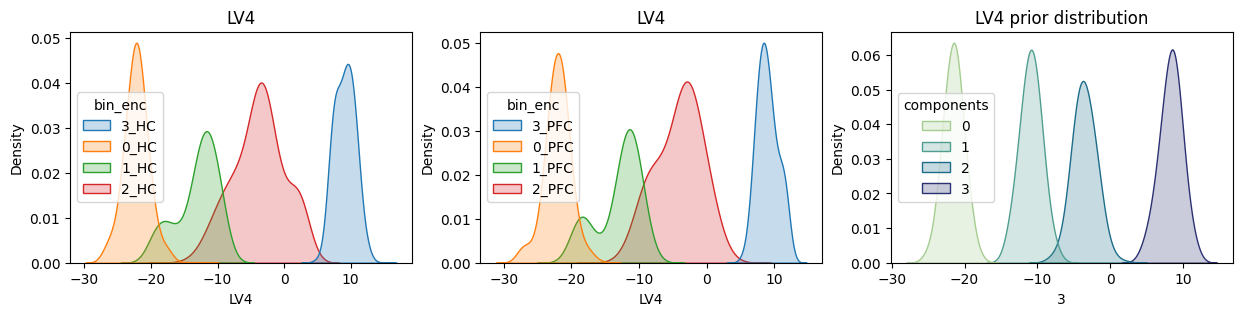

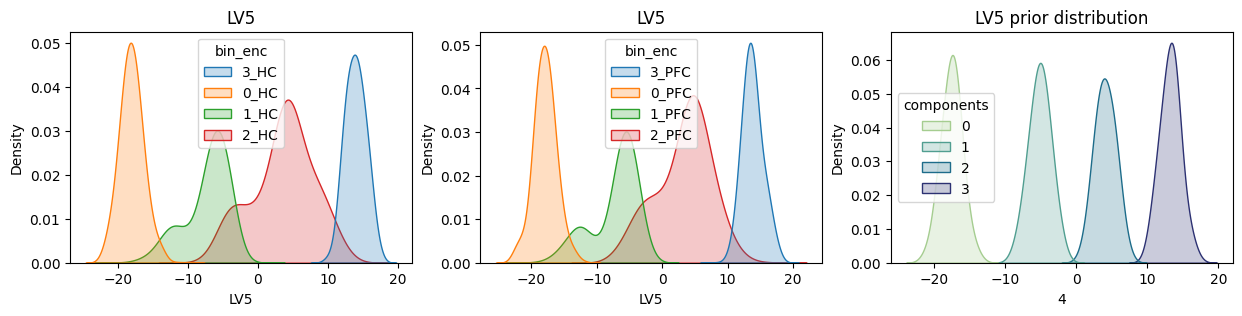

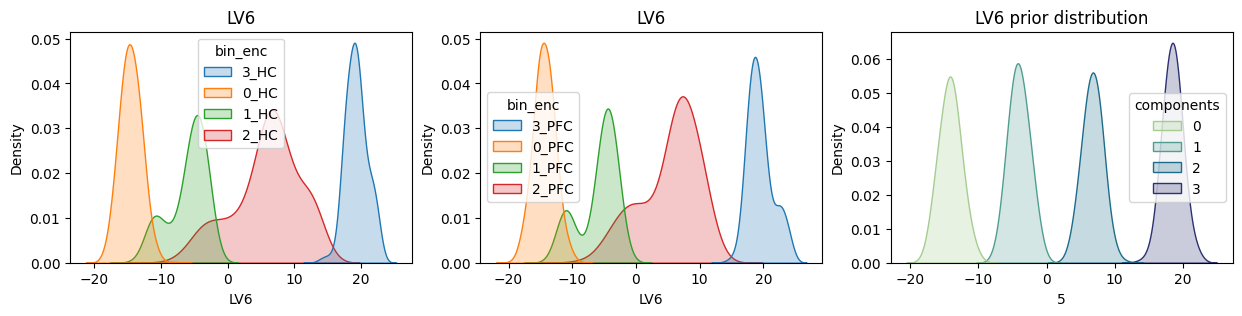

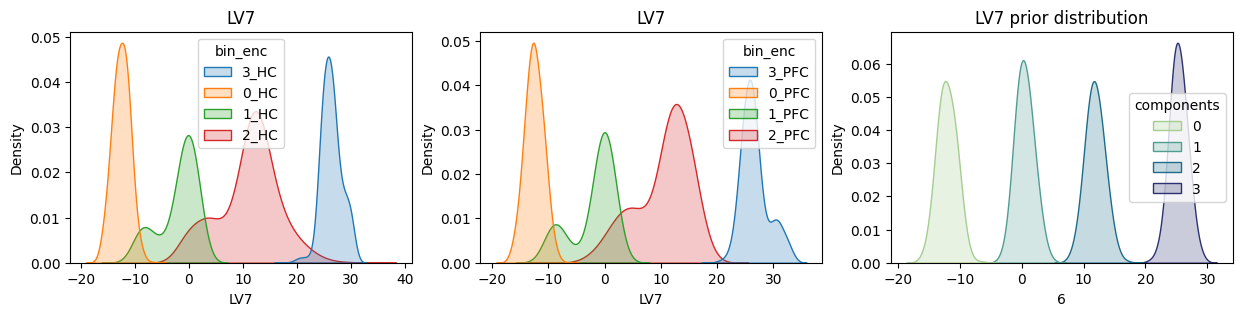

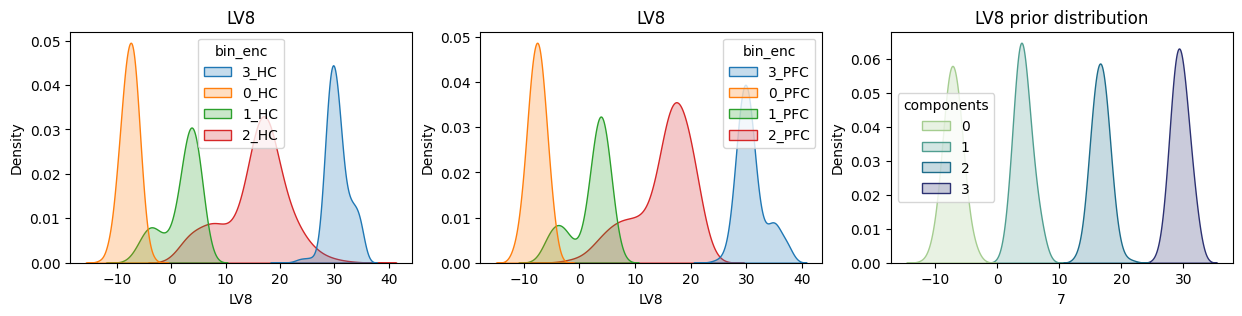

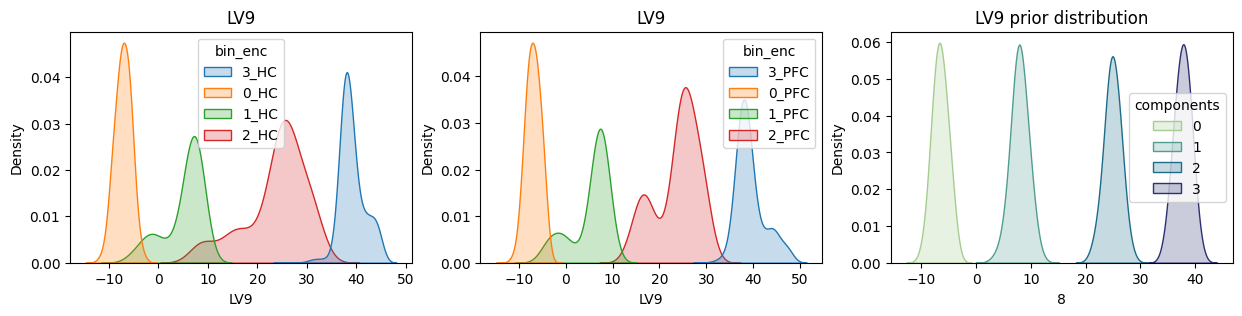

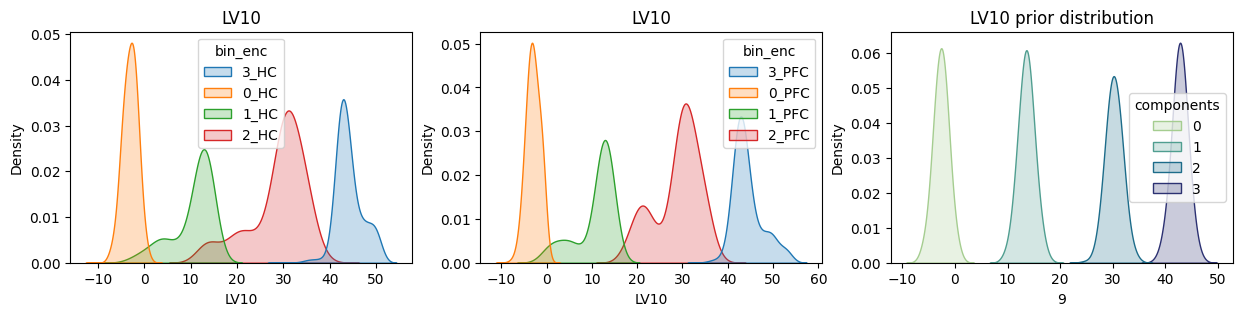

In [96]:
for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
    fig, ax = plt.subplots(1, 3, figsize=(15, 3))
    hc = latent_space_comb[latent_space_comb['bin_enc'].str.contains('HC')]
    sns.kdeplot(data=hc[[column, 'bin_enc']], x=column, hue='bin_enc', fill=True, bw_adjust=2, ax=ax[0])
    ax[0].set_title(column)
    pfc = latent_space_comb[latent_space_comb['bin_enc'].str.contains('PFC')]
    sns.kdeplot(data=pfc[[column, 'bin_enc']], x=column, hue='bin_enc', fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(column)
    prior_col = prior_samples.columns[i]
    sns.kdeplot(data=prior_samples[[prior_col, 'components']], x=prior_col, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[2])
    ax[2].set_title(f'{column} prior distribution')

In [32]:
# make umap object 
reducer = umap.UMAP(n_neighbors=50, min_dist=1, n_components=2, random_state=random_seed)
embedding = reducer.fit_transform(latent_space_comb.iloc[:, :latent_dim])

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [33]:
embedding_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
for hue in hues: 
    embedding_df[hue] = latent_space_comb[hue]

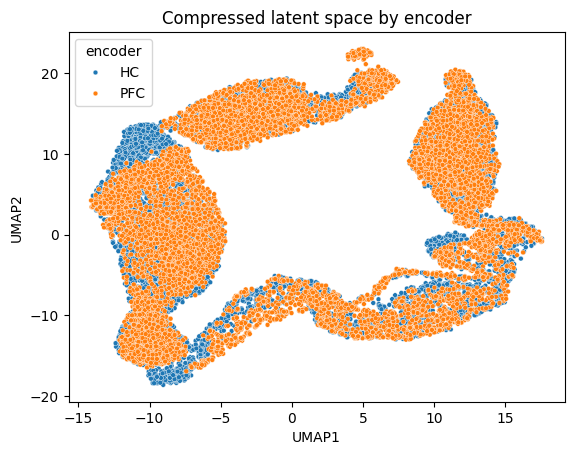

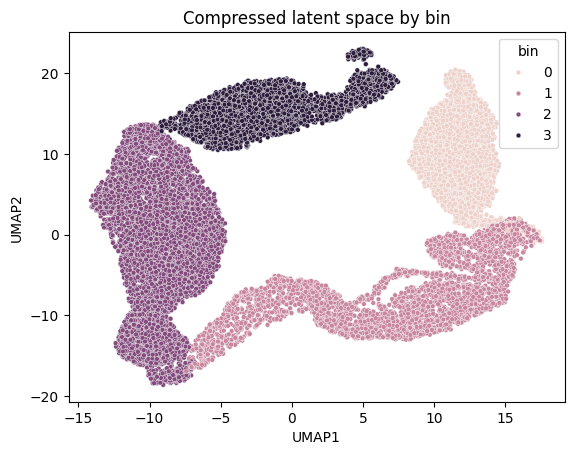

In [34]:
for hue in hues: 
    plt.figure()
    sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, data=embedding_df, s=12)
    plt.title(f'Compressed latent space by {hue}')

In [35]:
tsne = TSNE(n_components=2, perplexity=30, random_state=random_seed)
tsne_embeddings = tsne.fit_transform(latent_space_comb.iloc[:, :latent_dim])
tsne_embedding_df = pd.DataFrame(tsne_embeddings, columns=['t-SNE1', 't-SNE2'])
for hue in hues: 
    tsne_embedding_df[hue] = latent_space_comb[hue]

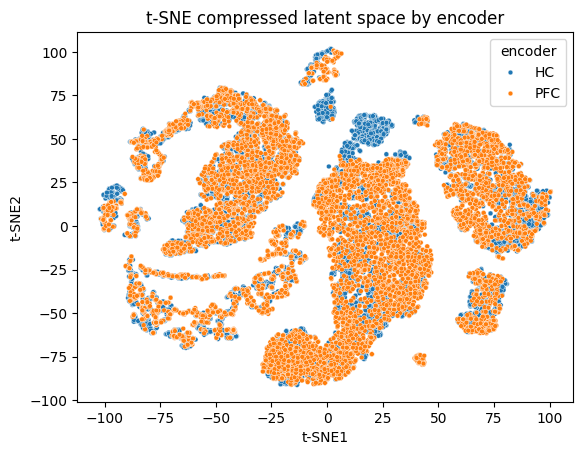

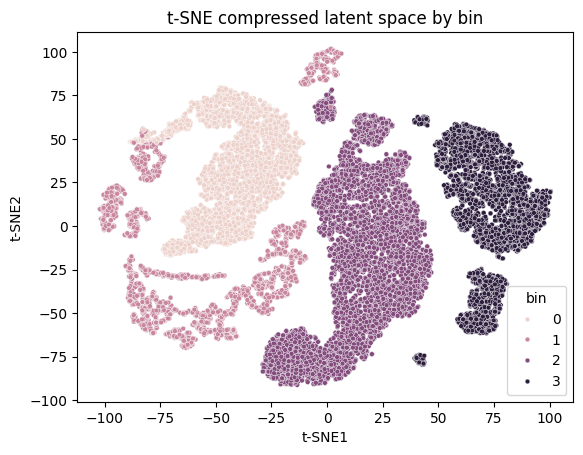

In [36]:
for hue in hues: 
    plt.figure()
    sns.scatterplot(x='t-SNE1', y='t-SNE2', hue=hue, data=tsne_embedding_df, s=12)
    plt.title(f't-SNE compressed latent space by {hue}')

Calculate and plot phenotypic projection

Latent space f-statistics

In [37]:
# latent_space_PFC = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr/train_normal_recon_10000epochs/latent_variables_epoch10000_vaePFC.csv')
# latent_space_PFC

In [38]:
# latent_space_HC = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr/train_normal_recon_10000epochs/latent_variables_epoch10000_vaeHC.csv')
# latent_space_HC

In [39]:
# latent_space_comb = pd.concat([latent_space_PFC, latent_space_HC])
# latent_space_comb = latent_space_comb.reset_index()
# latent_space_comb = latent_space_comb.iloc[:, 1:]

In [40]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif

le = LabelEncoder()
y = le.fit_transform(latent_space_comb['encoder'])
y

array([0, 0, 0, ..., 1, 1, 1])

In [41]:
f_values, p_values = f_classif(latent_space_comb.iloc[:, :latent_dim], y)
latents_ordered = np.argsort(f_values)
latents_ordered

array([0, 7, 8, 9, 1, 2, 4, 6, 3, 5])

In [42]:
latent_cols = latent_space_comb.iloc[:, :latent_dim].columns 
print('Latent feature variance correlations with encoder classification')
for col in latents_ordered:
    print(f'{latent_cols[col]}: {f_values[col], p_values[col]}')

Latent feature variance correlations with encoder classification
LV1: (6.199718197469055e-05, 0.9937177389024255)
LV8: (0.22759456152204632, 0.6333185357466956)
LV9: (0.24802797190131526, 0.6184726950372483)
LV10: (0.25688064225322804, 0.6122770712327181)
LV2: (0.2830211021926331, 0.5947339425781244)
LV3: (0.4191782798644399, 0.5173549733828785)
LV5: (0.46378200587225477, 0.495869818326769)
LV7: (0.5321178351762078, 0.46572659777825154)
LV4: (0.5336058734409544, 0.46510358407399577)
LV6: (0.7113912980076281, 0.39899266714900505)


Performing SVM

In [43]:
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from matplotlib.patches import Patch

In [44]:
svc = SVC(kernel="linear")
# svc.fit(latent_space_comb.iloc[:, :latent_dim], y)
weights = np.abs(model.coef_).mean(axis=0)
indices = np.argsort(weights)[::-1]
for i in indices: 
    print(f"{latent_cols[i]}: {weights[i]}")
# selector = RFE(svc, n_features_to_select=1, step=1)
# selector = selector.fit(latent_space_comb.iloc[:, :latent_dim], y)
# print('Latent variable ranking: ', selector.ranking_)

AttributeError: 'MM_CGMVAE' object has no attribute 'coef_'

In [ ]:
model.coef_

In [ ]:
weights = selector.estimator_.coef_[0]
weights

array([-0.05068967])

In [ ]:
svc.fit(latent_space_comb.iloc[:, :latent_dim], y)
all_weights = svc.coef_[0]
all_weights

array([ 0.22874072, -0.10289203, -0.03925901, -0.16684123,  0.19932943,
       -1.51030343,  0.40487123,  1.44046507, -0.26452169, -0.23622695])

Text(0, 0.5, 'SVM weight')

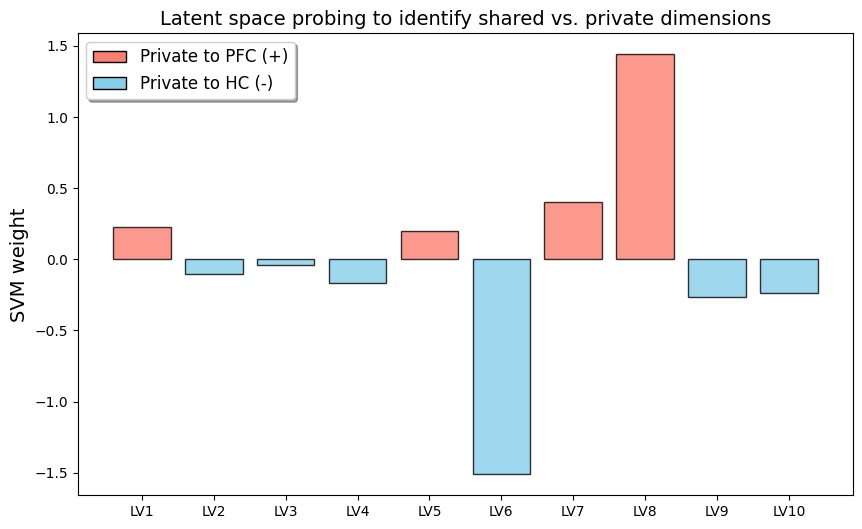

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['salmon' if w > 0 else 'skyblue' for w in all_weights]
ax.bar(latent_cols, all_weights, color=colors, edgecolor='black', alpha=0.8)

legend_elements = [
    Patch(facecolor='salmon', edgecolor='black', label=f'Private to {dataset_abbrev[1]} (+)'),
    Patch(facecolor='skyblue', edgecolor='black', label=f'Private to {dataset_abbrev[0]} (-)'),
    #Patch(facecolor='white', edgecolor='none', label='Close to 0 = Shared')
]

ax.legend(handles=legend_elements, loc='upper left', frameon=True, shadow=True, fontsize=12)
ax.set_title('Latent space probing to identify shared vs. private dimensions', fontsize=14)
ax.set_ylabel('SVM weight',  fontsize=14)